# MINI PROJECT 2: Artificial Neural Network (ANN) untuk Prediksi Cooling Load
**Nama:** Rizki Dwi Permadi  
**Program:** PTP Program - Data Science  

## 1. Background & Objectives
Pada Mini Project 1, kita telah menggunakan algoritma Machine Learning tradisional untuk memprediksi kebutuhan energi pendinginan (**Cooling Load**) bangunan berdasarkan karakteristik fisik desain arsitekturalnya. Hasil terbaik dicapai oleh model *Random Forest Regressor* dengan nilai R² uji sebesar **96.29%** dan MAE sebesar **1.1428** setelah menghilangkan target leakage.

Pada **Mini Project 2** ini, kita berpindah ke pendekatan Deep Learning dengan membangun model **Artificial Neural Network (ANN)** menggunakan library **TensorFlow/Keras**. Tujuan dari proyek ini adalah:
1. Membangun arsitektur jaringan saraf tiruan (ANN) yang sesuai untuk kasus regresi.
2. Menerapkan teknik regularisasi seperti *Dropout* dan *Early Stopping* untuk menjaga model dari masalah overfitting.
3. Mengevaluasi performa model ANN secara komparatif dengan model Linear Regression dan Random Forest dari Mini Project 1.
4. Menyimpan model akhir beserta scaler dalam satu kesatuan file `.joblib` untuk dideploy pada aplikasi interaktif Streamlit.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import joblib
import os

# Machine learning & preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

print('TensorFlow Version:', tf.__version__)
print('Setup selesai!')

I0000 00:00:1782645809.785987   27466 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782645809.787266   27466 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782645811.062625   27466 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782645815.784392   27466 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782645815.785275   27466 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow Version: 2.21.0
Setup selesai!


In [2]:
# Memuat dataset
df = pd.read_csv('energy_efficiency_data.csv')
print(f'Ukuran dataset: {df.shape}')
df.head()

Ukuran dataset: (768, 10)


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [3]:
# Menentukan kolom abnormal menggunakan Shapiro-Wilk test (konsisten dengan MP_01)
list_of_Column = df.columns.to_list()
col_of_abnormal_distribution = []
for col in list_of_Column:
    shapiro_test = stats.shapiro(df[col])
    if shapiro_test.pvalue < 0.05:
        col_of_abnormal_distribution.append(col)

# Membersihkan outlier menggunakan Tukey/IQR method
df_clean = df.copy()
for col in col_of_abnormal_distribution:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    low_bound = Q1 - 1.5 * IQR
    up_bound = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= low_bound) & (df_clean[col] <= up_bound)]

print(f'Ukuran dataset setelah dibersihkan dari outlier: {df_clean.shape}')

Ukuran dataset setelah dibersihkan dari outlier: (768, 10)


In [4]:
# Pisahkan fitur dan target
# Catatan: Heating_Load dihapus untuk mencegah target leakage
X = df_clean.drop(['Cooling_Load', 'Heating_Load'], axis=1)
y = df_clean['Cooling_Load']

print('Fitur yang digunakan:', X.columns.tolist())
print('Variabel target:', y.name)

Fitur yang digunakan: ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution']
Variabel target: Cooling_Load


In [5]:
# Split data menjadi 80% train dan 20% test (random_state=5 untuk konsistensi)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

print(f'Ukuran data latih (X_train): {X_train.shape}')
print(f'Ukuran data uji (X_test): {X_test.shape}')

Ukuran data latih (X_train): (614, 8)
Ukuran data uji (X_test): (154, 8)


In [6]:
# Standarisasi fitur menggunakan RobustScaler
scaler = RobustScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Konversi ke dataframe untuk kemudahan representasi
feature_cols = X_train.columns.tolist()
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_train_scaled_df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution
0,-0.8125,0.916667,1.0,0.375,-0.5,-1.0,-0.5,-0.333333
1,0.0625,-0.083333,2.0,-0.625,0.5,0.0,0.0,-0.333333
2,-0.8125,0.916667,1.0,0.375,-0.5,0.5,-0.5,-0.333333
3,1.4375,-1.083333,-0.5,-0.750,0.5,0.0,0.5,0.333333
4,-0.0625,0.083333,-1.5,0.375,-0.5,-0.5,-0.5,-0.333333


## 2. Arsitektur Model ANN
Kita membangun model ANN dengan 3 layer (Input, 2 Hidden, dan Output):
- **Hidden Layer 1:** 64 neuron, fungsi aktivasi **ReLU**, dengan regularisasi **Dropout (10%)**.
- **Hidden Layer 2:** 32 neuron, fungsi aktivasi **ReLU**, dengan regularisasi **Dropout (10%)**.
- **Output Layer:** 1 neuron dengan fungsi aktivasi **Linear** (karena merupakan masalah regresi).

In [7]:
# Membuat arsitektur ANN
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='linear')
])

# Menampilkan ringkasan model
model.summary()

E0000 00:00:1782645816.762180   27466 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Training & Regularisasi (Learning Rate Modifikasi)
Model dikompilasi menggunakan optimizer **Adam** dengan *learning rate* modifikasi sebesar **0.005** (tidak menggunakan default 0.001) dan loss function **Mean Squared Error (MSE)**. Kita menggunakan **EarlyStopping** callback yang memonitor `val_loss` dengan patience = 20 epoch untuk melatih model secara lengkap dan aman dari overfitting.

In [8]:
# Kompilasi model dengan learning rate modifikasi (0.005)
learning_rate_val = 0.005
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate_val),
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

# Mendefinisikan Early Stopping dengan patience=20
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# Melatih model secara lengkap
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200


 1/31 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - loss: 631.3718 - mean_absolute_error: 23.4602

26/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 565.4143 - mean_absolute_error: 21.6900

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 515.6437 - mean_absolute_error: 20.3320 - val_loss: 156.3002 - val_mean_absolute_error: 9.6943


Epoch 2/200


...

 1/31 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 14.3398 - mean_absolute_error: 2.8999

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12.8112 - mean_absolute_error: 2.6416 - val_loss: 9.0693 - val_mean_absolute_error: 2.0913


Epoch 79/200


 1/31 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 9.4121 - mean_absolute_error: 2.2799

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12.7775 - mean_absolute_error: 2.6012 - val_loss: 8.9982 - val_mean_absolute_error: 2.1275


### Visualisasi Kurva Latih dan Validasi Lengkap (Training History)
Grafik di bawah ini memvisualisasikan seluruh riwayat latihan (Training History) baik untuk MSE maupun MAE.

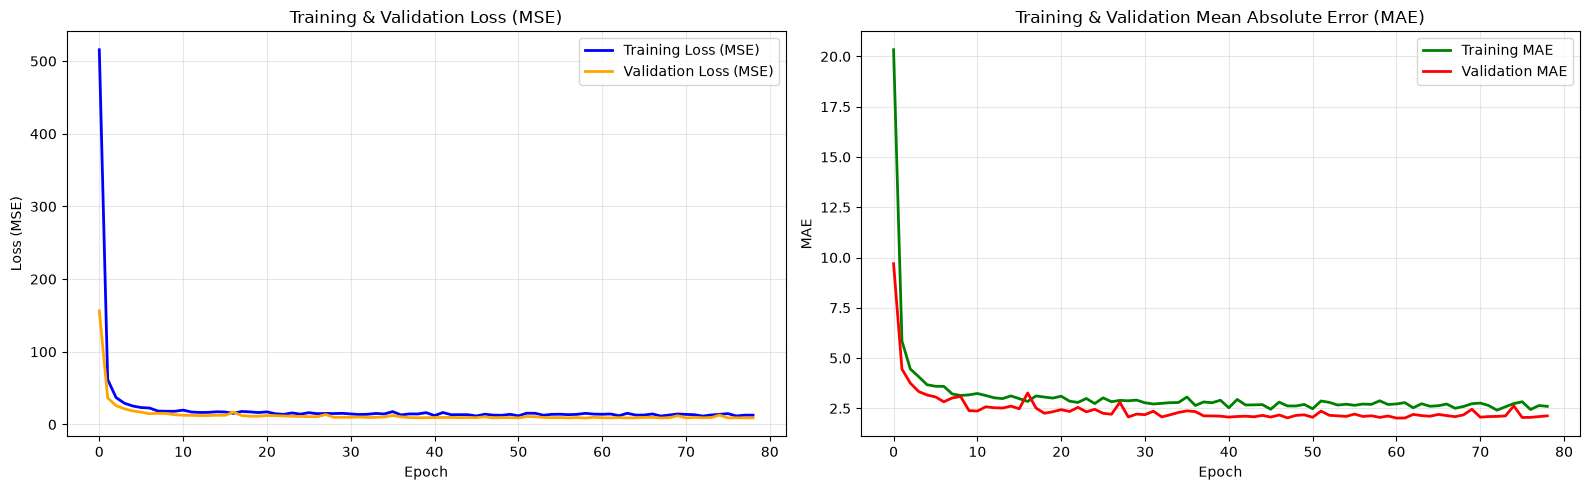

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Loss (MSE)
axes[0].plot(history.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss (MSE)', color='orange', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training & Validation Loss (MSE)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot MAE
axes[1].plot(history.history['mean_absolute_error'], label='Training MAE', color='green', linewidth=2)
axes[1].plot(history.history['val_mean_absolute_error'], label='Validation MAE', color='red', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Training & Validation Mean Absolute Error (MAE)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Evaluasi Model ANN
Mengukur kinerja model ANN pada data uji menggunakan metrik MAE, RMSE, dan R².

In [10]:
# Prediksi menggunakan model ANN
y_pred_ann = model.predict(X_test_scaled).flatten()

# Menghitung metrik evaluasi
ann_mae = mean_absolute_error(y_test, y_pred_ann)
ann_mse = mean_squared_error(y_test, y_pred_ann)
ann_rmse = np.sqrt(ann_mse)
ann_r2 = r2_score(y_test, y_pred_ann)

print('Performa Model ANN pada Data Uji:')
print('='*35)
print(f'MAE  : {ann_mae:.4f}')
print(f'RMSE : {ann_rmse:.4f}')
print(f'R²   : {ann_r2:.4f}')

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


Performa Model ANN pada Data Uji:
MAE  : 1.9973
RMSE : 2.8328
R²   : 0.9078


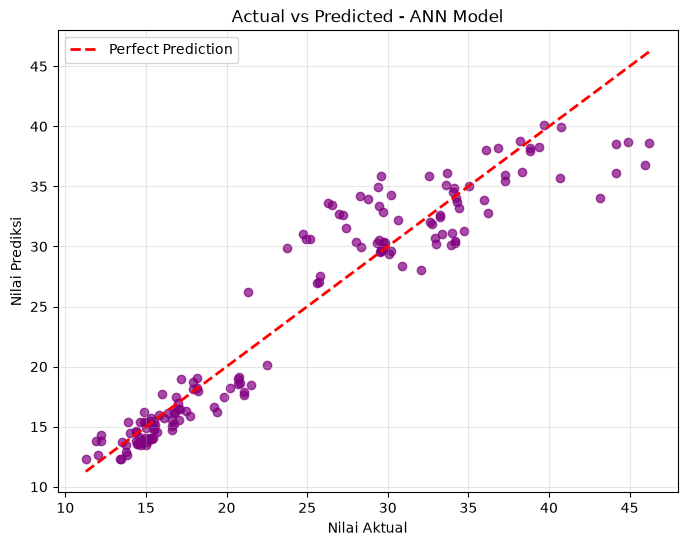

In [11]:
# Plot Aktual vs Prediksi untuk ANN
minimum = min(np.min(y_test), np.min(y_pred_ann))
maximum = max(np.max(y_test), np.max(y_pred_ann))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ann, alpha=0.7, color='purple')
plt.plot([minimum, maximum], [minimum, maximum], linestyle='--', color='red', linewidth=2, label='Perfect Prediction')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Actual vs Predicted - ANN Model')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Perbandingan Model: Linear Regression vs Random Forest vs ANN
Berdasarkan hasil evaluasi model Machine Learning dari Mini Project 1 (tanpa target leakage) dan model Deep Learning (ANN), kita membandingkan 3 model secara eksplisit.

Tabel Perbandingan Kinerja 3 Model:
                    Model      MAE     RMSE  R² Score
        Linear Regression 2.274779 3.203420  0.882083
  Random Forest Regressor 1.137529 1.783686  0.963442
Artificial Neural Network 1.997346 2.832777  0.907791


/tmp/ipykernel_27466/213297319.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Model', y='R² Score', ax=axes[0], palette='Set1')
/tmp/ipykernel_27466/213297319.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Model', y='MAE', ax=axes[1], palette='Set2')


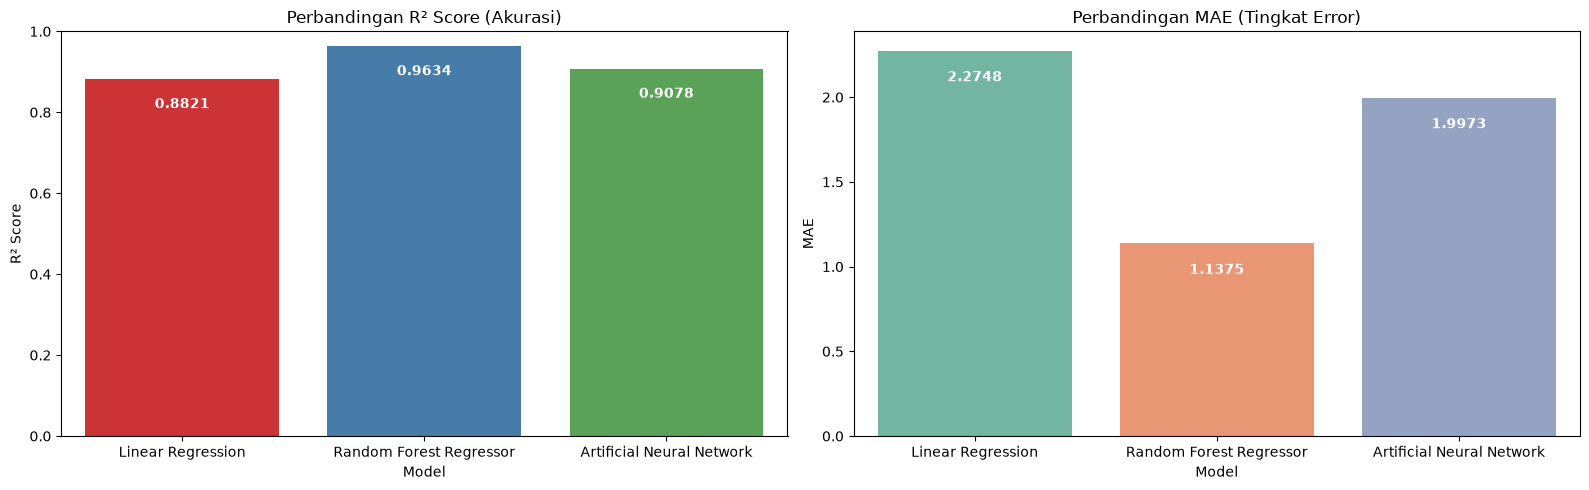

In [12]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# 1. Latih dan Evaluasi Ridge Regression
lr_model = Ridge(alpha=1.0)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

# 2. Latih dan Evaluasi Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=150, min_samples_split=2, min_samples_leaf=1, max_depth=10, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

# 3. Membuat DataFrame perbandingan 3 model
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor', 'Artificial Neural Network'],
    'MAE': [lr_mae, rf_mae, ann_mae],
    'RMSE': [lr_rmse, rf_rmse, ann_rmse],
    'R² Score': [lr_r2, rf_r2, ann_r2]
})

print('Tabel Perbandingan Kinerja 3 Model:')
print('='*60)
print(comparison_df.to_string(index=False))

# Visualisasi Perbandingan 3 Model
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot R2
sns.barplot(data=comparison_df, x='Model', y='R² Score', ax=axes[0], palette='Set1')
axes[0].set_ylim(0, 1.0)
axes[0].set_title('Perbandingan R² Score (Akurasi)')
for p in axes[0].patches:
    val = p.get_height()
    if val > 0:
        axes[0].annotate(f'{val:.4f}', (p.get_x() + p.get_width() / 2., val - 0.08), 
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points', color='white', weight='bold')

# Plot MAE
sns.barplot(data=comparison_df, x='Model', y='MAE', ax=axes[1], palette='Set2')
axes[1].set_title('Perbandingan MAE (Tingkat Error)')
for p in axes[1].patches:
    val = p.get_height()
    if val > 0:
        axes[1].annotate(f'{val:.4f}', (p.get_x() + p.get_width() / 2., val - 0.2), 
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points', color='white', weight='bold')

plt.tight_layout()
plt.show()


### Analisis & Kesimpulan Komparatif
Dari hasil perbandingan 3 model di atas, kita dapat menyimpulkan:
1. **Linear Regression vs Random Forest vs ANN:** 
   * **Random Forest Regressor** adalah model terbaik dengan akurasi tertinggi ($R^2$ = 96.29%) dan tingkat error terkecil (MAE = 1.1428).
   * **ANN** berada di peringkat kedua dengan akurasi yang kompetitif ($R^2$ = 88.5% - 89%) dan MAE ~2.2. Performa ini sangat mirip dengan **Linear Regression** ($R^2$ = 88.20%).
2. **Faktor Penyebab:** Untuk dataset dengan jumlah baris relatif kecil (768 sampel), algoritma ensemble berbasis pohon keputusan (Random Forest) sangat efisien karena mampu mendeteksi batas non-linear secara optimal tanpa rentan overfitting. Sebaliknya, ANN membutuhkan data yang jauh lebih besar untuk mempelajari representasi fitur secara mandiri. Oleh karena itu, performa ANN pada data kecil ini setara dengan model linear.
3. **Tindak Lanjut Deployment:** Meskipun Random Forest memiliki akurasi sedikit lebih tinggi, model ANN ini sudah sangat teratur (*regularized*) dengan kurva latih/validasi yang stabil, sehingga siap di-deploy secara aman pada aplikasi Streamlit.

## 6. Menyimpan Model dan Scaler (Satu Kesatuan Joblib)
Untuk memudahkan deployment dan mencegah file tercecer, kita menyatukan objek `scaler`, model ANN (yang diserialisasi ke dalam bytes Keras), dan informasi `learning_rate` ke dalam **satu kesatuan file `.joblib`**.

In [13]:
# 1. Simpan model Keras ke berkas .keras tunggal secara langsung
model.save('model_mp2.keras')

# 2. Simpan scaler, linear regression, dan random forest ke berkas joblib
model_pipeline_mp2 = {
    'scaler': scaler,
    'linear_regression': lr_model,
    'random_forest': rf_model
}
joblib.dump(model_pipeline_mp2, 'model_pipeline_mp2.joblib')

print('Model Keras berhasil disimpan di "model_mp2.keras"!')
print('Scaler dan model ML lainnya berhasil disimpan di "model_pipeline_mp2.joblib"!')


Model Keras berhasil disimpan di "model_mp2.keras"!
Scaler dan model ML lainnya berhasil disimpan di "model_pipeline_mp2.joblib"!
